# Dense Neural Network (DNN)
Name: Arya Ghilman Winarto

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
import tensorflow as tf
print(tf.__version__)

from tensorflow import keras
from tensorflow.keras import layers

2.19.0


In [3]:
import random
seed_value = 99

#7 42 47 99 101

random.seed(seed_value)
np.random.seed(seed_value)

tf.random.set_seed(seed_value)  # For TensorFlow

In [4]:
df = pd.read_csv(r"/Users/aryawinarto/Downloads/CEMS CO2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50371 entries, 0 to 50370
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0    FLOW     50371 non-null  float64
 1    FUEL     50371 non-null  float64
 2    PSUC     50371 non-null  float64
 3    PDIS     50371 non-null  float64
 4    CAIT     50371 non-null  float64
 5    IGV      50371 non-null  float64
 6    LOAD     50371 non-null  float64
 7    PTS      50371 non-null  float64
 8    EXHT     50371 non-null  float64
 9   EMISSION  50371 non-null  float64
dtypes: float64(10)
memory usage: 3.8 MB


- Dropping EMISSION from the feature set as it is used only for the target set

In [5]:
feature_cols = df.drop('EMISSION', axis=1)
target = df['EMISSION'].values

In [6]:
feature_cols_train, feature_cols_test, target_train, target_test = train_test_split(feature_cols, target, test_size=0.33, random_state=42)

- Epoch  refers to one complete pass through the entire training dataset once by the neural network which includes one forwards pass and one backward pass.

- Forward pass: The model takes inputs, perform predictions, and compute errors.
- Backward pass: The model adjusts its weights based on the errors to improve future predictions.

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

In [7]:
from tensorflow.keras import regularizers

#L1 = 0.001

#tf.keras.layers.Dense(32, activation='elu',kernel_regularizer=regularizers.l1),

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='elu', input_shape=(feature_cols_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(1)
])

/Users/aryawinarto/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.001), 
              loss='mse', 
              metrics=['mse'])

Early Stopping
- Pragmatic approach to control overfitting by monitoring the model's error on a validation set and stopping the training process when the error starts to increase.
- The validation set is the data set of examples used to tune the hyperparameters of a model

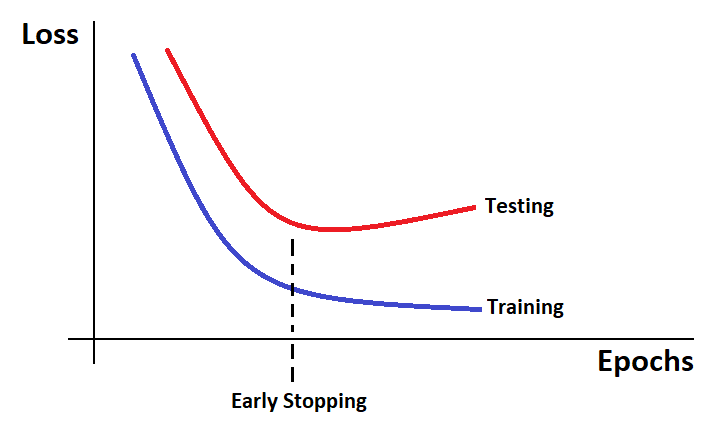

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=0, mode='min', restore_best_weights=True)

In [10]:
history = model.fit(
    feature_cols_train, target_train,
    validation_data=(feature_cols_test, target_test),
    epochs= 100,
    batch_size=8,
    verbose=1,
    callbacks=[early_stopping]  # Add early stopping callback
) 

epochs_trained = len(history.history['loss'])

Epoch 1/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 758us/step - loss: 13381.1074 - mse: 13381.1074 - val_loss: 46.3908 - val_mse: 46.3908
Epoch 2/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 720us/step - loss: 39.8685 - mse: 39.8685 - val_loss: 23.5988 - val_mse: 23.5988
Epoch 3/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 719us/step - loss: 20.5129 - mse: 20.5129 - val_loss: 12.6592 - val_mse: 12.6592
Epoch 4/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 735us/step - loss: 11.1140 - mse: 11.1140 - val_loss: 7.2224 - val_mse: 7.2224
Epoch 5/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 715us/step - loss: 6.4334 - mse: 6.4334 - val_loss: 4.5021 - val_mse: 4.5021
Epoch 6/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 728us/step - loss: 4.0991 - mse: 4.0991 - val_loss: 3.1431 - val_mse: 3.1431
Epoch 7/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 754us/step - loss: 2.9381 - mse: 2.9381 - val_loss: 2.4627 - val_mse: 2.4627
Epoch 8/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 3s 737us/step - loss: 2.3595 - mse: 2.3595 - val_loss: 2.1217 - val_mse: 2.1

In [11]:
test_loss, test_mse = model.evaluate(feature_cols_test, target_test)
print(f"Test Loss: {test_loss}, Test MSE: {test_mse}")

520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 1.6130 - mse: 1.6130
Test Loss: 1.6127431392669678, Test MSE: 1.6127431392669678


How to detect overfitting?

- We need a way to test it on unseen data. 
- We often leverage a technique called "Cross Validation" whenever we want to evaluate the performance of a model on unseen instances.

Overfitting can be avoided using regularisation. Regularisation regularise the model by adding information which creates a solution that prevents overfitting.

L1 Regularisation 

- Also known as norm or Lasso, combats overfitting by shrinking the parameters towards 0 thus making some features obsolete. 
- Feature that does not provide significant effect would be assigned 0 by the L1 Regularisation technique.

L2 Regularisation

- Combats overfitting by shrinking the parameters closer to 0 but not 0 whilst making some features less impactful.

In [12]:
target_pred = model.predict(feature_cols_test)
print("R2:" + str(r2_score(target_test, target_pred)))
print("RMSE:" + str(np.sqrt(mean_squared_error(target_test, target_pred))))

520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step
R2:0.8786585340972997
RMSE:1.2699382508076558


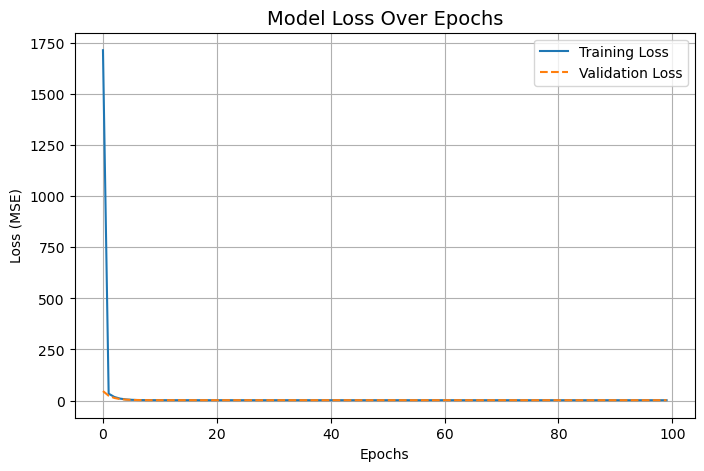

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')  
plt.legend()
plt.grid(True)
plt.show()

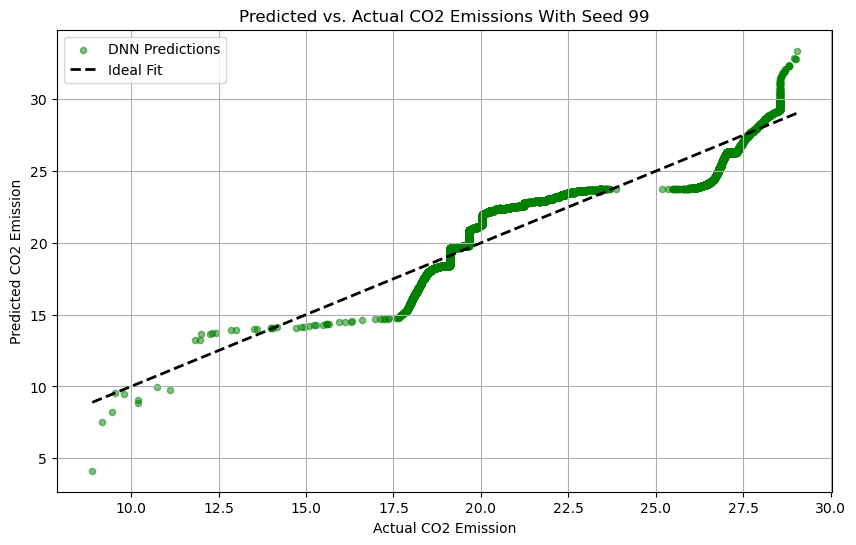

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(target_test, target_pred, label='DNN Predictions', color='green', alpha=0.5, s=20)
plt.plot([target_test.min(), target_test.max()], [target_test.min(), target_test.max()], 
         'k--', lw=2, label='Ideal Fit')
plt.xlabel('Actual CO2 Emission')
plt.ylabel('Predicted CO2 Emission')
plt.title(f'Predicted vs. Actual CO2 Emissions With Seed {seed_value}')
plt.legend()
plt.grid(True)
plt.show()

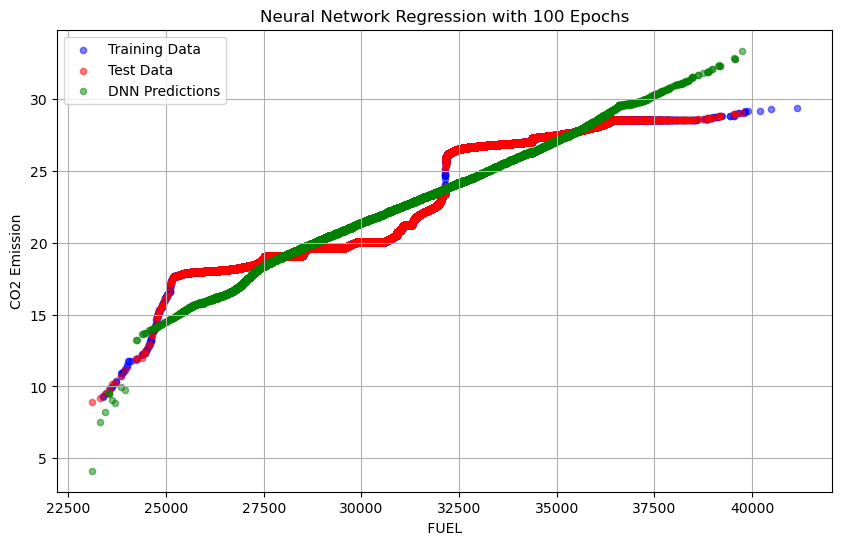

In [15]:
feature_idx = 1  # 'LOAD' column
feature_name = feature_cols.columns[feature_idx]

plt.figure(figsize=(10, 6))

plt.scatter(feature_cols_train.iloc[:, feature_idx], target_train, 
            label='Training Data', color='blue', alpha=0.5, s=20)

plt.scatter(feature_cols_test.iloc[:, feature_idx], target_test, 
            label='Test Data', color='red', alpha=0.5, s=20)

plt.scatter(feature_cols_test.iloc[:, feature_idx], target_pred, 
            label='DNN Predictions', color='green', alpha=0.5, s=20)

plt.xlabel(f'{feature_name}')
plt.ylabel('CO2 Emission')
plt.title(f'Neural Network Regression with {epochs_trained} Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def predict_co2():
    FLOW = float(76)
    FUEL = float(23109.04)
    PSUC = float(19.96)
    PDIS = float(111.71)
    CAIT = float(73.7)
    IGV = float(8.99)
    LOAD = float(21.4)
    PTS = float(3827.62)
    EXHT = float(913.9)
    
    new_data = [[FLOW, FUEL, PSUC, PDIS, CAIT, IGV, LOAD, PTS, EXHT]]
    
    column_names = ['FLOW', 'FUEL', 'PSUC', 'PDIS', 'CAIT', 'IGV', 'LOAD', 'PTS', 'EXHT']
    new_data_df = pd.DataFrame(new_data, columns=column_names)
    
    co2_prediction = model.predict(new_data_df)
    print(f"Predicted CO2: {co2_prediction[0]}")

predict_co2()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted CO2: [4.1422544]
